# Gradient descent algorithm implementation from scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#our loss function f(x) = (x-3)^2
def objective(x):
    return (x-3)**2

In [ ]:
# aka the derivative of loss function
def gradient(x):
    return 2*(x-3)

In [ ]:
x = 0.0
loss = objective(x)
grad = gradient(x)

print(loss)
print(grad)

In [ ]:
# calculating new X based on learning rate and the gradient value from previous value
def calculate_new_x(learning_rate, x):
    new_x = x - learning_rate * gradient(x)
    print(f"X:",x)
    print(f"loss: ", objective(x))
    print(f"gradient: ", gradient(x))


    print(f"New X:", new_x)
    print(f"loss: ", objective(new_x))
    print(f"gradient: ", gradient(new_x), "\n")


    return new_x

calculate_new_x(0.1, -2)
calculate_new_x(0.1, 0)
calculate_new_x(0.1, 3)
calculate_new_x(0.1, 10)

## Checkpoint questions:

### Why?:
- #### A negative gradient means increasing x should reduce the objective.
  Because when a gradient is negative, means x should increase, and thus coming closer to grad being 0 (aka derivative being 0). For the example above, when we start with x = -2, gradient is -10. Updated x in that case is now -1 (new_x = x - learning_rate * gradient), and as we approach x = 3 gradient is closer and closer to one)
- #### A positive gradient means decreasing x should reduce the objective.
  It is the exact opposite situation here, basically when gradient is positive, means we are on the right side of the loss function (x-3)^2. Meaning we should go left to achieve gradient as close to 0
- #### A zero gradient means there is no local first-order direction of improvement.
  Because we are at the point, where objective is 0, the loss is 0, meaning we are 100% correctly predicted target.

- #### Why do you subtract the gradient?
  When gradient is negative, subtracting the negative gradient results in addition, (moving right, closer to local minimum)
- #### What does the learning rate control?
  It controls how big the difference between x and new_x is. Too big of a learning rate can result in x hopping right and left over the local minimum
- #### Why should the new loss be lower?
  If the learning rate is optimal, the gradient always gives a direction, in which to move the new x, thus, making it approach a local minimum, thus making a prediction more accurate
- #### Is a lower loss guaranteed for every learning rate?
  Not really, as mentioned just above, too big of a learning rate can result in loss jumping over the minimum. Too low learning rate will still reduce the loss, but potentially to a really really small difference, almost negligible, which results in slower convergence

In [ ]:
# implementing history for x, loss, gradients

x_hist = []
objective_hist = []
gradient_hist = []

x = -2
learning_rate = 0.3
max_iterations = 10

for iteration in range(max_iterations):
    x_hist.append(x)
    loss = objective(x)
    grad = gradient(x)
    x = x - learning_rate * grad
    print(loss, grad, x, iteration)
    
    objective_hist.append(loss)
    gradient_hist.append(grad)

print(x_hist)
print(objective_hist)
print(gradient_hist)

In [ ]:
sorted_data = sorted(zip(x_hist, objective_hist, gradient_hist), key=lambda item: item[0])
x_sorted, loss_sorted, grad_sorted = zip(*sorted_data)

# 3. Create the plots
plt.figure(figsize=(8, 5))
plt.plot(x_sorted, loss_sorted, label="Loss", color="blue", marker="o", linewidth=2)
plt.plot(x_sorted, grad_sorted, label="Gradient", color="orange", marker="s", linewidth=2)

plt.xlabel("X Value")
plt.ylabel("Output Value")
plt.title("Loss and Gradient vs. X")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Reference line at y=0
plt.axvline(0, color='black', linestyle='--', linewidth=0.8) # Reference line at x=0
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

In [ ]:
learning_rates = [
    0.001,
    0.01,
    0.1,
    0.4,
    0.9,
    1.0,
    1.1,
]

x_hist = []
objective_hist = []
gradient_hist = []
x = -3

for lr in learning_rates:
    print(f"\n--- RUNNING LEARNING RATE: {lr} ---")
    
    x = -3
    x_hist = []
    objective_hist = []
    gradient_hist = []
    
    for iteration in range(max_iterations):
        x_hist.append(x)
        loss = objective(x)
        grad = gradient(x)
        
        x = x - lr * grad
        print(f"Iter {iteration}: Loss={loss:.4f}, Grad={grad:.4f}, Next X={x:.4f}")
        
        objective_hist.append(loss)
        gradient_hist.append(grad)
        
    sorted_data = sorted(zip(x_hist, objective_hist, gradient_hist), key=lambda item: item[0])
    x_sorted, loss_sorted, grad_sorted = zip(*sorted_data)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x_sorted, loss_sorted, label=f"Loss (lr={lr})", color="blue", marker="o", linewidth=2)
    plt.plot(x_sorted, grad_sorted, label=f"Gradient (lr={lr})", color="orange", marker="s", linewidth=2)
    
    plt.xlabel("X Value")
    plt.ylabel("Output Value")
    plt.title(f"Optimization Path with Learning Rate = {lr}")
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    plt.show()

## Stage 6 - adding stopping conditions to the optimizer & Stage 7 - determining wrong behaviour

Adding several tolerance based stop conditions to the optimizer:
- Gradient tolerance
  Stop when: ∣f′(x)∣<ε
- Parameter-change tolerance
  Stop when: ∣(xt+1)−xt∣<ε
- Loss-change tolerance
  Stop when:∣f(xt+1)−f(xt)∣<ε
- Maximum iterations
  Always keep a maximum iteration limit to prevent infinite loops.

Validate inputs:
- Learning rate must be positive.
- Maximum iterations must be positive.
- Tolerance must not be negative.
- Initial parameters must be finite.

In [ ]:
def gradient_tolerance(gradient, tolerance):
    if abs(gradient) < tolerance:
        return False
    return True
def param_change_tolerance(old_param, new_param, tolerance):
    if abs(new_param - old_param) < tolerance:
        return False
    return True
def loss_change_tolerance(old_loss, new_loss, tolerance):
    if abs(new_loss - old_loss) < tolerance:
        return False
    return True

In [ ]:
x_hist = []
objective_hist = []
gradient_hist = []
x = -3
max_iterations = 1000
tolerance = 1e-6

learning_rates = [
    0.1,
    0.4,
    0.9
]

def grad_descent(x, lr, max_iterations, tolerance):
    print(f"\n--- RUNNING LEARNING RATE: {lr} ---")
    if np.isnan(x) or np.isinf(x):
        raise ValueError("Starting parameters (x) must be finite and numeric.")
    if tolerance < 0:
        raise ValueError("Tolerance must be positive.")
    if lr <= 0:  # Changed to <= because a learning rate of 0 will loop forever
        raise ValueError("Learning rate must be greater than zero.")
    if max_iterations <= 0:  # Changed to <= because 0 iterations means it won't run
        raise ValueError("Max iterations must be greater than zero.")
    
    for iteration in range(max_iterations):
        x_hist.append(x)
        loss = objective(x)
        grad = gradient(x)
        
        new_x = x - lr * grad
        new_loss = objective(new_x)
        print(f"Iter {iteration}: Loss={loss:.4f}, Grad={grad:.4f}, Next X={new_x:.4f}")
        
        objective_hist.append(loss)
        gradient_hist.append(grad)

        # stopping conditions
        if not gradient_tolerance(grad, tolerance):
            break
        # if not param_change_tolerance(x, new_x, tolerance):
        #     break
        # if not loss_change_tolerance(loss, new_loss, tolerance):
        #     break
        x = new_x
        loss = new_loss

        # checking part
        if np.isnan(loss):
            raise ValueError("loss is not a number")
            break
        if np.isinf(loss):
            raise ValueError("loss is not a number")
            break
        if np.isnan(grad):
            raise ValueError("Gradient is not a number")
            break
        if np.isinf(grad):
            raise ValueError("Gradient is not finite")
            break

for lr in learning_rates:
    x_hist = []
    objective_hist = []
    gradient_hist = []
    grad_descent(x, lr, max_iterations, tolerance)
        
    sorted_data = sorted(zip(x_hist, objective_hist, gradient_hist), key=lambda item: item[0])
    x_sorted, loss_sorted, grad_sorted = zip(*sorted_data)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x_sorted, loss_sorted, label=f"Loss (lr={lr})", color="blue", marker="o", linewidth=2)
    plt.plot(x_sorted, grad_sorted, label=f"Gradient (lr={lr})", color="orange", marker="s", linewidth=2)
    
    plt.xlabel("X Value")
    plt.ylabel("Output Value")
    plt.title(f"Optimization Path with Learning Rate = {lr}")
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    plt.show()

In [ ]:
def numerical_gradient(objective, x, epsilon=1e-5):
    return (objective(x + epsilon) - objective(x - epsilon)) / (2 * epsilon)

In [ ]:
x_hist = []
objective_hist = []
gradient_hist = []
x = -3
max_iterations = 1000
tolerance = 1e-6

learning_rates = [
    0.1,
    0.4,
    0.9
]

def grad_descent(x, lr, max_iterations, tolerance):
    print(f"\n--- RUNNING LEARNING RATE: {lr} ---")
    if np.isnan(x) or np.isinf(x):
        raise ValueError("Starting parameters (x) must be finite and numeric.")
    if tolerance < 0:
        raise ValueError("Tolerance must be positive.")
    if lr <= 0:  # Changed to <= because a learning rate of 0 will loop forever
        raise ValueError("Learning rate must be greater than zero.")
    if max_iterations <= 0:  # Changed to <= because 0 iterations means it won't run
        raise ValueError("Max iterations must be greater than zero.")
    
    for iteration in range(max_iterations):
        x_hist.append(x)
        loss = objective(x)
        grad = gradient(x)
        num_grad = numerical_gradient(objective, x, tolerance)
        
        new_x = x - lr * grad
        new_loss = objective(new_x)
        print(f"Iter {iteration}: Loss={loss:.4f}, Grad={grad:.4f}, Numerical Grad={num_grad:.4f}, Next X={new_x:.4f}")
        
        objective_hist.append(loss)
        gradient_hist.append(grad)

        # stopping conditions
        if not gradient_tolerance(grad, tolerance):
            break
        # if not param_change_tolerance(x, new_x, tolerance):
        #     break
        # if not loss_change_tolerance(loss, new_loss, tolerance):
        #     break
        x = new_x
        loss = new_loss

        # checking part
        if np.isnan(loss):
            raise ValueError("loss is not a number")
            break
        if np.isinf(loss):
            raise ValueError("loss is not a number")
            break
        if np.isnan(grad):
            raise ValueError("Gradient is not a number")
            break
        if np.isinf(grad):
            raise ValueError("Gradient is not finite")
            break

for lr in learning_rates:
    x_hist = []
    objective_hist = []
    gradient_hist = []
    grad_descent(x, lr, max_iterations, tolerance)
        
    sorted_data = sorted(zip(x_hist, objective_hist, gradient_hist), key=lambda item: item[0])
    x_sorted, loss_sorted, grad_sorted = zip(*sorted_data)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x_sorted, loss_sorted, label=f"Loss (lr={lr})", color="blue", marker="o", linewidth=2)
    plt.plot(x_sorted, grad_sorted, label=f"Gradient (lr={lr})", color="orange", marker="s", linewidth=2)
    
    plt.xlabel("X Value")
    plt.ylabel("Output Value")
    plt.title(f"Optimization Path with Learning Rate = {lr}")
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    plt.show()

## Part III — Generalize to multiple parameters. Stage 9 — Replace the scalar with a vector

In [ ]:
import numpy as np

def objective(parameters):
    x, y = parameters
    return (x - 2) ** 2 + 3 * (y + 1) ** 2

def gradient(parameters):
    x, y = parameters

    return np.array([
        2 * x - 4,
        6 * y + 6,
    ], dtype=float)

def numerical_gradient(objective_function, parameters, epsilon=1e-5):
    parameters = np.asarray(parameters, dtype=float)
    result = np.zeros_like(parameters)

    for index in range(parameters.size):
        parameters_plus = parameters.copy()
        parameters_minus = parameters.copy()

        parameters_plus[index] += epsilon
        parameters_minus[index] -= epsilon

        result[index] = (
            objective_function(parameters_plus)
            - objective_function(parameters_minus)
        ) / (2 * epsilon)

    return result

def gradient_descent(
    initial_parameters,
    learning_rate,
    max_iterations=1000,
    tolerance=1e-6,
):
    if learning_rate <= 0:
        raise ValueError("Learning rate must be greater than zero.")
    if max_iterations <= 0:
        raise ValueError("Maximum iterations must be greater than zero.")
    if tolerance <= 0:
        raise ValueError("Tolerance must be greater than zero.")
        
    parameters = np.asarray(
        initial_parameters,
        dtype=float,
    ).copy()
    
    if parameters.shape != (2,):
        raise ValueError("This objective requires exactly two parameters.")

    if not np.all(np.isfinite(parameters)):
        raise ValueError("Starting parameters must be finite.")

    parameter_history = []
    objective_history = []
    gradient_history = []

    converged = False
    stopping_reason = "maximum_iterations"

    print(f"\n--- LEARNING RATE: "f"{learning_rate} ---")

    for iteration in range(max_iterations):
        loss = objective(parameters)
        grad = gradient(parameters)

        numeric_grad = numerical_gradient(
            objective,
            parameters,
            epsilon=1e-5,
        )

        if not np.isfinite(loss):
            stopping_reason = "non_finite_loss"
            break

        if not np.all(np.isfinite(grad)):
            stopping_reason = "non_finite_gradient"
            break

        parameter_history.append(parameters.copy())
        objective_history.append(loss)
        gradient_history.append(grad.copy())

        # unlike the case where we had only one parameter x, which we could directly use to calculate gradient_tolerance, 
        # here we have x and y parameters, the norm of which has to be calculated first: sqrt(x**2 + y**2)
        gradient_norm = np.linalg.norm(grad)

        print(
            f"Iteration {iteration:4d} | "
            f"parameters={np.array2string(parameters, precision=5)} | "
            f"loss={loss:.8f} | "
            f"gradient={np.array2string(grad, precision=5)} | "
            f"numerical={np.array2string(numeric_grad, precision=5)} | "
            f"norm={gradient_norm:.3e}"
        )

        if gradient_norm < tolerance:
            converged = True
            stopping_reason = "gradient_tolerance"
            break

        new_parameters = (parameters - learning_rate * grad)

        new_loss = objective(new_parameters)

        if (
            not np.all(np.isfinite(new_parameters))
            or not np.isfinite(new_loss)
        ):
            stopping_reason = "non_finite_update"
            break

        parameters = new_parameters

    return {
        "parameters": parameters,
        "loss": objective(parameters),
        "converged": converged,
        "reason": stopping_reason,
        "parameter_history": np.array(parameter_history),
        "objective_history": np.array(objective_history),
        "gradient_history": np.array(gradient_history),
    }

In [ ]:
initial_parameters = np.array([-3, -4], dtype=float)

learning_rates = [0.1, 0.2]

results = {}

for learning_rate in learning_rates:
    results[learning_rate] = gradient_descent(
        initial_parameters=np.array(
            [-3, -4],
            dtype=float,
        ),
        learning_rate=learning_rate,
        max_iterations=1000,
        tolerance=1e-6,
    )
    print("\nFinal parameters:", results[learning_rate]["parameters"])
    print("Final loss:", results[learning_rate]["loss"])
    print("Converged:", results[learning_rate]["converged"])
    print("Reason:", results[learning_rate]["reason"])

In [ ]:
# plotting the results

for learning_rate, result in results.items():
    history = result["parameter_history"]

    plt.figure(figsize=(8, 4))

    plt.plot(history[:, 0], label="x")
    plt.plot(history[:, 1], label="y")

    plt.axhline(2, linestyle="--", label="optimal x")
    plt.axhline(-1, linestyle="--", label="optimal y")

    plt.xlabel("Iteration")
    plt.ylabel("Parameter value")
    plt.title(
        f"Parameter convergence, lr={learning_rate}"
    )
    plt.legend()
    plt.grid()

    plt.show()

## Part IV — Apply gradient descent to linear regression. 
### Stage 12 — Build a prediction function

In [ ]:
def predict(X, weights, bias):
    return X @ weights + bias

# aka = y = 3x + 2 function

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true-y_pred)**2)

def calculate_gradients(X, y, weights, bias):
    n_samples = X.shape[0]

    predictions = predict(X, weights, bias)
    errors = predictions - y

    weights_gradient = (2 / n_samples) * X.T @ errors
    bias_gradient = (2 / n_samples) * np.sum(errors)

    return weights_gradient, bias_gradient

def fit_linear_regression_gd(X, y, learning_rate=0.1, max_iterations=1000, tolerance=1e-6):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    weights = np.zeros(X.shape[1], dtype=float)
    bias = 0.0

    loss_history = []

    for iteration in range(max_iterations):
        predictions = predict(X, weights, bias)
        loss = mean_squared_error(y, predictions)

        weight_gradient, bias_gradient = calculate_gradients(X, y, weights, bias)

        gradient_norm  = np.sqrt(np.sum(weight_gradient ** 2) + bias_gradient ** 2)

        loss_history.append(loss)

        if gradient_norm < tolerance:
            break

        weights = weights - learning_rate * weight_gradient
        bias = bias - learning_rate * bias_gradient
    return weights, bias, loss_history

# Usage:

# X = np.array([[-2], [-1], [0], [1], [2]], dtype=float)
# y = np.array([-4, -1, 2, 5, 8], dtype=float)

# weights, bias, loss_history = fit_linear_regression_gd(X, y, 0.3, 1000, 1e-6)

# print(f"Weights: ", weights)
# print(f"Bias: ", bias)
# print(f"Loss history: ", np.asarray(loss_history, dtype=float))

# Comparison with numpy least squares method

In [ ]:
X = np.array([0, 1, 2, 3], dtype=float)
y = np.array([-1, 0.2, 0.9, 2.1], dtype=float)

A = np.vstack([X, np.ones(len(X))]).T
print(A)

solution, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
# 4. Extract results

m, c = solution
print("Numpy's least squares solution: ")
print(f"Slope (m): {m:.4f}")         # Output: ~1.0000
print(f"Intercept (c): {c:.4f}")     # Output: ~-0.9500
print(f"Residual sum: {residuals[0]:.4f}")

X = np.array([[0], [1], [2], [3]], dtype=float)
print("---------------")
print("My gradient_descent solution (objective is y = wx + b):")
weight, bias, loss_history = fit_linear_regression_gd(X, y, 0.1, 1000, 1e-6)

print(f"Weight: {weight[0]:.4f}")
print(f"Bias: {bias:.4f}")
print(f"Loss: {loss_history[-1]:.4f}")

# Comparison with sklearn linear regression

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = np.array([[0], [1], [2], [3]], dtype=float)
y = np.array([-1, 0.2, 0.9, 2.1], dtype=float)

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(f"Intercept (b): {model.intercept_}")
print(f"Slope/Coefficients (w): {model.coef_}")

print(f"Mean Squared Error (MSE): {mean_squared_error(y, y_pred):.4f}")

print("---------------")
print("My gradient_descent solution (objective is y = wx + b):")
weight, bias, loss_history = fit_linear_regression_gd(X, y, 0.1, 1000, 1e-6)

print(f"Weight: {weight[0]:.4f}")
print(f"Bias: {bias:.4f}")
print(f"Loss (MSE): {loss_history[-1]:.4f}")

# Plot results
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Sklearn linear regression results")
plt.legend()
plt.grid()
plt.show()

predictions = predict(X, weight, bias)

plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, predictions, color="red", linewidth=2, label="Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("My implementation results")
plt.legend()
plt.grid()
plt.show()

### Checking with generated datasets with make_regression from sklearn
- Case 1: <b>1 feature, no noise:</b> 
    Slope/Coefficients (w): [87.73730719]
    Intercept (b): 4.440892098500626e-16
    Mean Squared Error (MSE): 0.0000
    
    My gradient_descent solution (objective is y = wx + b):
    Weight: [87.73730719]
    Bias: -4.2492838834158184e-16
    Loss (MSE): 0.0000

- Case 2: <b>Multiple features, no noise:</b>
    Slope/Coefficients (w): [70.64757265 16.74825823 10.45678403 63.64302495  3.15861448]
    Intercept (b): -3.108624468950438e-14
    Mean Squared Error (MSE): 0.0000
    
    My gradient_descent solution (objective is y = wx + b):
    Weight: [70.64757265 16.74825823 10.45678403 63.64302495  3.15861448]
    Bias: -4.317241685242683e-16
    Loss (MSE): 0.0000

- Case 3: <b>Many irrelevant features</b>
    Slope/Coefficients (w): [ 6.91144401e-15  2.30926389e-14 -1.70974346e-14  6.55031585e-15
      2.53130850e-14 -2.12052598e-14 -9.36750677e-15 -5.66213743e-15
      1.95399252e-14 -3.66373598e-14 -4.97379915e-14  8.18740229e+01
      1.22124533e-14 -5.32907052e-15  3.05311332e-15]
    Intercept (b): -1.942890293094024e-15
    Mean Squared Error (MSE): 0.0000
    
    My gradient_descent solution (objective is y = wx + b):
    Weight: [ 1.05133739e-16 -1.40672516e-16 -1.38705733e-16  1.03097649e-16
      2.45175308e-16  2.05365522e-16  4.66738487e-16  8.09698606e-18
      1.35524442e-16 -1.92370468e-16 -2.40546560e-17  8.18740229e+01
      2.43890058e-16 -9.64364575e-17 -3.57842874e-16]
    Bias: 2.6105377935734735e-16
    Loss (MSE): 0.0000

- Case 4: <b>Correlated features</b>
    Slope/Coefficients (w): [25.9670839  25.28581183 81.87402295 43.12338698 96.97236328 57.76317543
     61.39703063 69.20112559 35.9208747   5.27652579 22.6521626  45.79289944
     98.35672065 34.75187953  5.0349527 ]
    Intercept (b): -3.552713678800501e-15
    Mean Squared Error (MSE): 0.0000
    
    My gradient_descent solution (objective is y = wx + b):
    Weight: [25.9670839  25.28581183 81.87402295 43.12338698 96.97236328 57.76317543
     61.39703063 69.20112559 35.9208747   5.27652579 22.6521626  45.79289944
     98.35672065 34.75187953  5.0349527 ]
    Bias: 5.5428831066038505e-15
    Loss (MSE): 0.0000

- Case 5: <b>Differently scaled features</b>:
Original feature standard deviation: 
[0.93710937 0.99795804 1.02724235]
Badly scaled feature standard deviation:
[9.37109370e-01 9.97958045e+01 1.02724235e+04]
Slope/Coefficients (w): [2.67669923e+01 8.28650223e-01 5.01203638e-03]
Intercept (b): 4.870707084281513
Mean Squared Error (MSE): 97.2878

    My gradient_descent solution (objective is y = wx + b):
    Weight: [0.00017089 0.06255413 0.00531186]
    Bias: 4.425594100996256e-05
    Loss (MSE): 6454.3595


    *Notice that here i had to bring down the learning rate to 4e-12'ish to even prevent overflow*

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

X, y, true_coef = make_regression(
    n_samples=500,
    n_features=3,
    n_informative=3,
    noise=10,
    bias=5,
    coef=True,
    random_state=42,
)

# differently scaled features experiment setup
print("Original feature standard deviation: ")
print(X.std(axis=0))
scale_factors = np.array([
    1.0,
    100.0,
    10000.0
])
X = X * scale_factors
print("Badly scaled feature standard deviation:")
print(f"{X.std(axis=0)} \n")

# Scaling the features back to their norm
scaler = StandardScaler()
X = scaler.fit_transform(X)



# print(len(X), X)
# print(len(y), y)

#sklearn fitting
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(f"Slope/Coefficients (w): {model.coef_}")
print(f"Intercept (b): {model.intercept_}")

print(f"Mean Squared Error (MSE): {mean_squared_error(y, y_pred):.4f}")

print("---------------")
print("My gradient_descent solution (objective is y = wx + b):")
weight, bias, loss_history = fit_linear_regression_gd(X, y, 4e-1, 1000, 1e-16)

print(f"Weight: {weight}")
print(f"Bias: {bias}")
print(f"Loss (MSE): {loss_history[-1]:.4f}")

# Plot results
# plt.scatter(X, y, color="blue", label="Actual Data")
# plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")
# plt.xlabel("X")
# plt.ylabel("y")
# plt.title("Sklearn linear regression results")
# plt.legend()
# plt.grid()
# plt.show()

# predictions = predict(X, weight, bias)

# plt.scatter(X, y, color="blue", label="Actual Data")
# plt.plot(X, predictions, color="red", linewidth=2, label="Regression Line")
# plt.xlabel("X")
# plt.ylabel("y")
# plt.title("My implementation results")
# plt.legend()
# plt.grid()
# plt.show()

## Testing on real dataset (Diabetes regression dataset from sklearn)

Full dataset shape: (442, 10)
Target shape: (442,)

Training feature means after scaling:
[-0. -0. -0. -0. -0.  0. -0. -0. -0.  0.]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

SCIKIT-LEARN LINEAR REGRESSION
------------------------------
Training MSE: 2868.549703
Test MSE:     2900.193628
Training R²:  0.527919
Test R²:      0.452603

CUSTOM GRADIENT DESCENT
-----------------------
Training MSE: 2868.549703
Test MSE:     2900.193597
Training R²:  0.527919
Test R²:      0.452603

PARAMETER COMPARISON
--------------------

Scikit-learn weights:
[  1.75375799 -11.51180908  25.60712144  16.82887167 -44.44885564
  24.64095356   7.67697768  13.1387839   35.16119521   2.35136365]

Gradient-descent weights:
[  1.7537582  -11.511809    25.60712218  16.82887143 -44.4488171
  24.64092341   7.67696068  13.13877861  35.16118042   2.35136393]

Coefficient L2 distance: 0.0000541407
Scikit-learn bias: 153.7365439093
Gradient-descent bias: 153.7365439093
Bias difference: 0.0

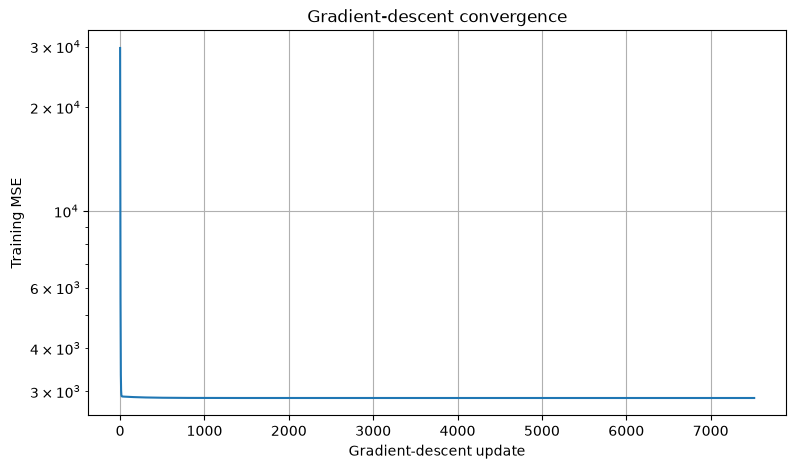

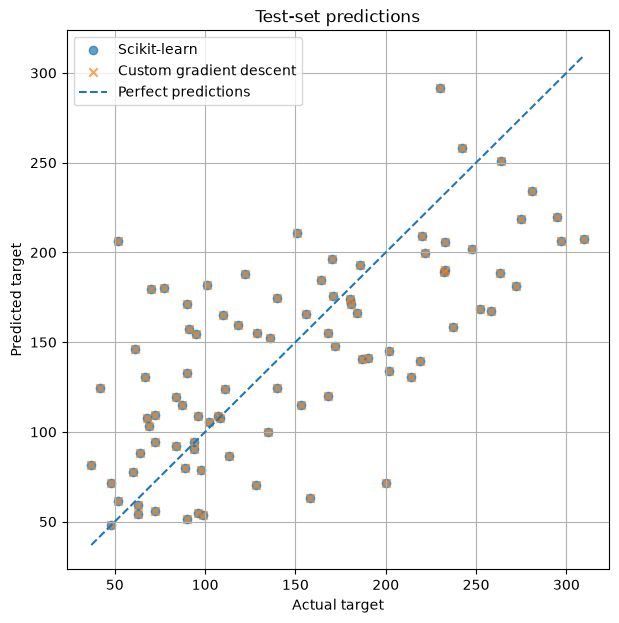

In [14]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. Custom linear regression components
# ============================================================

def predict(
    X: np.ndarray,
    weights: np.ndarray,
    bias: float,
) -> np.ndarray:
    """Return linear-regression predictions."""
    return X @ weights + bias


def calculate_gradients(
    X: np.ndarray,
    y: np.ndarray,
    weights: np.ndarray,
    bias: float,
) -> tuple[np.ndarray, float]:
    """
    Calculate gradients of mean squared error with respect
    to the weights and bias.
    """
    n_samples = X.shape[0]

    predictions = predict(X, weights, bias)
    errors = predictions - y

    weight_gradient = (2.0 / n_samples) * (X.T @ errors)
    bias_gradient = 2.0 * np.mean(errors)

    return weight_gradient, float(bias_gradient)


def fit_linear_regression_gd(
    X: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.1,
    max_iterations: int = 20_000,
    tolerance: float = 1e-6,
) -> dict:
    """
    Train linear regression using batch gradient descent.

    Returns the fitted parameters, loss history, convergence
    information, and final gradient norm.
    """
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    # ----------------------------
    # Input validation
    # ----------------------------

    if X.ndim != 2:
        raise ValueError("X must be a 2D array.")

    if y.ndim != 1:
        raise ValueError("y must be a 1D array.")

    if X.shape[0] != y.shape[0]:
        raise ValueError(
            "X and y must contain the same number of samples."
        )

    if X.shape[0] == 0:
        raise ValueError("The training dataset cannot be empty.")

    if learning_rate <= 0:
        raise ValueError(
            "Learning rate must be greater than zero."
        )

    if max_iterations <= 0:
        raise ValueError(
            "Maximum iterations must be greater than zero."
        )

    if tolerance <= 0:
        raise ValueError(
            "Tolerance must be greater than zero."
        )

    if not np.all(np.isfinite(X)):
        raise ValueError("X contains NaN or infinite values.")

    if not np.all(np.isfinite(y)):
        raise ValueError("y contains NaN or infinite values.")

    # ----------------------------
    # Parameter initialization
    # ----------------------------

    n_features = X.shape[1]

    weights = np.zeros(n_features, dtype=np.float64)
    bias = 0.0

    initial_predictions = predict(X, weights, bias)
    initial_loss = mean_squared_error(y, initial_predictions)

    # Each value represents the loss at the current parameters.
    loss_history = [initial_loss]

    converged = False
    stopping_reason = "maximum_iterations"
    updates_completed = 0

    # ----------------------------
    # Optimization
    # ----------------------------

    for _ in range(max_iterations):
        weight_gradient, bias_gradient = calculate_gradients(
            X,
            y,
            weights,
            bias,
        )

        gradient_norm = np.sqrt(
            np.dot(weight_gradient, weight_gradient)
            + bias_gradient**2
        )

        if not np.isfinite(gradient_norm):
            raise FloatingPointError(
                "Gradient became NaN or infinite."
            )

        # Stop before another update when the objective
        # is sufficiently flat.
        if gradient_norm < tolerance:
            converged = True
            stopping_reason = "gradient_tolerance"
            break

        new_weights = (
            weights
            - learning_rate * weight_gradient
        )

        new_bias = (
            bias
            - learning_rate * bias_gradient
        )

        if not np.all(np.isfinite(new_weights)):
            raise FloatingPointError(
                "Weights became NaN or infinite. "
                "The learning rate may be too large."
            )

        if not np.isfinite(new_bias):
            raise FloatingPointError(
                "Bias became NaN or infinite. "
                "The learning rate may be too large."
            )

        weights = new_weights
        bias = float(new_bias)
        updates_completed += 1

        current_predictions = predict(
            X,
            weights,
            bias,
        )

        current_loss = mean_squared_error(
            y,
            current_predictions,
        )

        if not np.isfinite(current_loss):
            raise FloatingPointError(
                "Loss became NaN or infinite. "
                "The learning rate may be too large."
            )

        loss_history.append(current_loss)

    # Recalculate final gradient at the returned parameters.
    final_weight_gradient, final_bias_gradient = (
        calculate_gradients(
            X,
            y,
            weights,
            bias,
        )
    )

    final_gradient_norm = np.sqrt(
        np.dot(
            final_weight_gradient,
            final_weight_gradient,
        )
        + final_bias_gradient**2
    )

    final_predictions = predict(
        X,
        weights,
        bias,
    )

    final_loss = mean_squared_error(
        y,
        final_predictions,
    )

    return {
        "weights": weights,
        "bias": bias,
        "initial_loss": initial_loss,
        "final_loss": final_loss,
        "loss_history": np.asarray(loss_history),
        "updates_completed": updates_completed,
        "converged": converged,
        "stopping_reason": stopping_reason,
        "final_gradient_norm": final_gradient_norm,
    }


# ============================================================
# 2. Load raw diabetes data
# ============================================================

X, y = load_diabetes(
    return_X_y=True,
    scaled=False,
)

print("Full dataset shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 3. Split before scaling
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)


# ============================================================
# 4. Fit scaler only on training data
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining feature means after scaling:")
print(np.round(X_train_scaled.mean(axis=0), 6))

print("\nTraining feature standard deviations:")
print(np.round(X_train_scaled.std(axis=0), 6))


# ============================================================
# 5. Scikit-learn reference model
# ============================================================

sklearn_model = LinearRegression()

sklearn_model.fit(
    X_train_scaled,
    y_train,
)

sklearn_train_predictions = sklearn_model.predict(
    X_train_scaled
)

sklearn_test_predictions = sklearn_model.predict(
    X_test_scaled
)


# ============================================================
# 6. Custom gradient-descent model
# ============================================================

gd_result = fit_linear_regression_gd(
    X_train_scaled,
    y_train,
    learning_rate=0.1,
    max_iterations=20_000,
    tolerance=1e-6,
)

gd_weights = gd_result["weights"]
gd_bias = gd_result["bias"]

gd_train_predictions = predict(
    X_train_scaled,
    gd_weights,
    gd_bias,
)

gd_test_predictions = predict(
    X_test_scaled,
    gd_weights,
    gd_bias,
)


# ============================================================
# 7. Metric helper
# ============================================================

def evaluate_model(
    name: str,
    y_train: np.ndarray,
    train_predictions: np.ndarray,
    y_test: np.ndarray,
    test_predictions: np.ndarray,
) -> None:
    train_mse = mean_squared_error(
        y_train,
        train_predictions,
    )

    test_mse = mean_squared_error(
        y_test,
        test_predictions,
    )

    train_r2 = r2_score(
        y_train,
        train_predictions,
    )

    test_r2 = r2_score(
        y_test,
        test_predictions,
    )

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Training MSE: {train_mse:.6f}")
    print(f"Test MSE:     {test_mse:.6f}")
    print(f"Training R²:  {train_r2:.6f}")
    print(f"Test R²:      {test_r2:.6f}")


evaluate_model(
    name="SCIKIT-LEARN LINEAR REGRESSION",
    y_train=y_train,
    train_predictions=sklearn_train_predictions,
    y_test=y_test,
    test_predictions=sklearn_test_predictions,
)

evaluate_model(
    name="CUSTOM GRADIENT DESCENT",
    y_train=y_train,
    train_predictions=gd_train_predictions,
    y_test=y_test,
    test_predictions=gd_test_predictions,
)


# ============================================================
# 8. Compare parameters and predictions
# ============================================================

coefficient_distance = np.linalg.norm(
    gd_weights - sklearn_model.coef_
)

bias_difference = abs(
    gd_bias - sklearn_model.intercept_
)

mean_train_prediction_difference = np.mean(
    np.abs(
        gd_train_predictions
        - sklearn_train_predictions
    )
)

mean_test_prediction_difference = np.mean(
    np.abs(
        gd_test_predictions
        - sklearn_test_predictions
    )
)

maximum_test_prediction_difference = np.max(
    np.abs(
        gd_test_predictions
        - sklearn_test_predictions
    )
)

print("\nPARAMETER COMPARISON")
print("--------------------")

print("\nScikit-learn weights:")
print(sklearn_model.coef_)

print("\nGradient-descent weights:")
print(gd_weights)

print(
    f"\nCoefficient L2 distance: "
    f"{coefficient_distance:.10f}"
)

print(
    f"Scikit-learn bias: "
    f"{sklearn_model.intercept_:.10f}"
)

print(
    f"Gradient-descent bias: "
    f"{gd_bias:.10f}"
)

print(
    f"Bias difference: "
    f"{bias_difference:.10f}"
)


print("\nPREDICTION COMPARISON")
print("---------------------")

print(
    f"Mean training prediction difference: "
    f"{mean_train_prediction_difference:.10f}"
)

print(
    f"Mean test prediction difference: "
    f"{mean_test_prediction_difference:.10f}"
)

print(
    f"Maximum test prediction difference: "
    f"{maximum_test_prediction_difference:.10f}"
)


# ============================================================
# 9. Convergence report
# ============================================================

print("\nGRADIENT-DESCENT CONVERGENCE")
print("----------------------------")

print(
    f"Initial training loss: "
    f"{gd_result['initial_loss']:.6f}"
)

print(
    f"Final training loss:   "
    f"{gd_result['final_loss']:.6f}"
)

print(
    f"Last history value:    "
    f"{gd_result['loss_history'][-1]:.6f}"
)

print(
    f"Updates completed:     "
    f"{gd_result['updates_completed']}"
)

print(
    f"Converged:             "
    f"{gd_result['converged']}"
)

print(
    f"Stopping reason:       "
    f"{gd_result['stopping_reason']}"
)

print(
    f"Final gradient norm:   "
    f"{gd_result['final_gradient_norm']:.10e}"
)


# ============================================================
# 10. Plot training loss
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(gd_result["loss_history"])

plt.xlabel("Gradient-descent update")
plt.ylabel("Training MSE")
plt.title("Gradient-descent convergence")
plt.yscale("log")
plt.grid()

plt.show()


# ============================================================
# 11. Plot actual versus predicted test targets
# ============================================================

minimum_value = min(
    y_test.min(),
    sklearn_test_predictions.min(),
    gd_test_predictions.min(),
)

maximum_value = max(
    y_test.max(),
    sklearn_test_predictions.max(),
    gd_test_predictions.max(),
)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    sklearn_test_predictions,
    alpha=0.7,
    label="Scikit-learn",
)

plt.scatter(
    y_test,
    gd_test_predictions,
    alpha=0.7,
    marker="x",
    label="Custom gradient descent",
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect predictions",
)

plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Test-set predictions")
plt.legend()
plt.grid()

plt.show()

## Running LinearRegressionGD i extracted from notebook to python files.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_diabetes, make_regression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from gradient_descent import gradient_descent
from linear_regression import LinearRegressionGD

def quadratic_objective(parameters):
    x, y = parameters

    return ((x - 2) ** 2 + 3 * (y + 1) ** 2)

def quadratic_gradient(parameters):
    x, y = parameters

    return np.array([2 * (x - 2), 6 * (y + 1)], dtype=float)

quadratic_result = gradient_descent(
    objective=quadratic_objective,
    gradient=quadratic_gradient,
    initial_parameters=np.array(
        [-3.0, -4.0]
    ),
    learning_rate=0.1,
    max_iterations=1_000,
    gradient_tolerance=1e-8,
)

print("Parameters:", quadratic_result.parameters)
print("Loss:", quadratic_result.loss)
print("Converged:", quadratic_result.converged)
print("Reason:", quadratic_result.stopping_reason)
print("Iterations:", quadratic_result.iterations)

Parameters: [ 2. -1.]
Loss: 2.3587264620615693e-17
Converged: True
Reason: gradient_tolerance
Iterations: 93


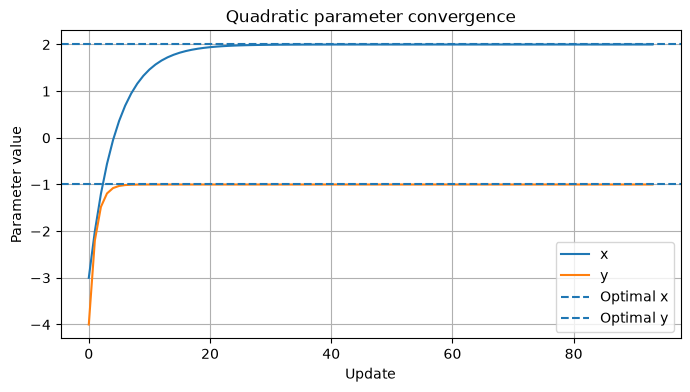

In [2]:
history = quadratic_result.parameter_history

plt.figure(figsize=(8, 4))

plt.plot(
    history[:, 0],
    label="x",
)

plt.plot(
    history[:, 1],
    label="y",
)

plt.axhline(
    2,
    linestyle="--",
    label="Optimal x",
)

plt.axhline(
    -1,
    linestyle="--",
    label="Optimal y",
)

plt.xlabel("Update")
plt.ylabel("Parameter value")
plt.title("Quadratic parameter convergence")
plt.legend()
plt.grid()

plt.show()

In [3]:
X, y, true_coefficients = make_regression(
    n_samples = 500,
    n_features = 5,
    n_informative = 5,
    noise = 10,
    bias = 5,
    coef = True,
    random_state = 42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
gd_model = LinearRegressionGD(
    learning_rate=0.1,
    max_iterations=20_000,
    gradient_tolerance=1e-8,
)

gd_model.fit(
    X_train_scaled,
    y_train,
)

gd_train_predictions = gd_model.predict(
    X_train_scaled
)

gd_test_predictions = gd_model.predict(
    X_test_scaled
)

print("Weights:", gd_model.coef_)
print("Bias:", gd_model.intercept_)

print(
    "Converged:",
    gd_model.optimization_result_.converged,
)

print(
    "Reason:",
    gd_model.optimization_result_.stopping_reason,
)

print(
    "Final gradient norm:",
    
    gd_model.optimization_result_.gradient_norm,
)

Weights: [27.8090904  76.51520534 30.65215088 72.43721167 10.39294495]
Bias: 8.25783402059942
Converged: True
Reason: gradient_tolerance
Final gradient norm: 9.773696149788095e-09


### Comparing with sklearn

In [6]:
sklearn_model = LinearRegression()

sklearn_model.fit(X_train_scaled, y_train)

sklearn_train_predictions = sklearn_model.predict(X_train_scaled)
sklearn_test_predictions = sklearn_model.predict(X_test_scaled)

print("CUSTOM GRADIENT DESCENT")
print(
    "Train MSE:",
    mean_squared_error(
        y_train,
        gd_train_predictions,
    ),
)
print(
    "Test MSE:",
    mean_squared_error(
        y_test,
        gd_test_predictions,
    ),
)
print(
    "Test R²:",
    r2_score(
        y_test,
        gd_test_predictions,
    ),
)


print("\nSCIKIT-LEARN")
print(
    "Train MSE:",
    mean_squared_error(
        y_train,
        sklearn_train_predictions,
    ),
)
print(
    "Test MSE:",
    mean_squared_error(
        y_test,
        sklearn_test_predictions,
    ),
)
print(
    "Test R²:",
    r2_score(
        y_test,
        sklearn_test_predictions,
    ),
)

CUSTOM GRADIENT DESCENT
Train MSE: 89.6016058716554
Test MSE: 106.32500047145595
Test R²: 0.9910587469987538

SCIKIT-LEARN
Train MSE: 89.60160587165541
Test MSE: 106.3250004668955
Test R²: 0.9910587469991373


In [7]:
coefficient_distance = np.linalg.norm(
    gd_model.coef_
    - sklearn_model.coef_
)

bias_difference = abs(
    gd_model.intercept_
    - sklearn_model.intercept_
)

mean_prediction_difference = np.mean(
    np.abs(
        gd_test_predictions
        - sklearn_test_predictions
    )
)

print(
    "Coefficient distance:",
    coefficient_distance,
)

print(
    "Bias difference:",
    bias_difference,
)

print(
    "Mean test prediction difference:",
    mean_prediction_difference,
)

Coefficient distance: 5.35069102306608e-09
Bias difference: 1.4449597074417397e-10
Mean test prediction difference: 4.47065111153222e-09


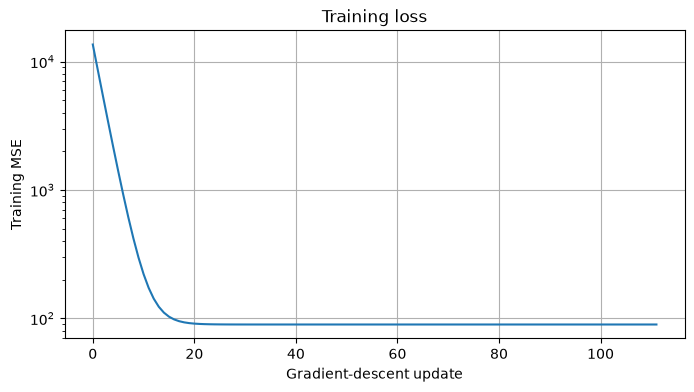

In [8]:
plt.figure(figsize=(8, 4))

plt.plot(
    gd_model.loss_history_
)

plt.xlabel("Gradient-descent update")
plt.ylabel("Training MSE")
plt.title("Training loss")
plt.yscale("log")
plt.grid()

plt.show()

In [9]:
learning_rates = [
    0.001,
    0.01,
    0.05,
    0.1,
    0.5,
]

learning_rate_results = {}

for learning_rate in learning_rates:
    model = LinearRegressionGD(
        learning_rate=learning_rate,
        max_iterations=5_000,
        gradient_tolerance=1e-8,
    )

    try:
        model.fit(
            X_train_scaled,
            y_train,
        )

        learning_rate_results[
            learning_rate
        ] = model

        result = model.optimization_result_

        print(
            f"lr={learning_rate:<6} "
            f"loss={result.loss:.6f} "
            f"iterations={result.iterations:<5} "
            f"converged={result.converged} "
            f"reason={result.stopping_reason}"
        )

    except FloatingPointError as error:
        print(
            f"lr={learning_rate:<6} "
            f"failed: {error}"
        )

lr=0.001  loss=89.601631 iterations=5000  converged=False reason=maximum_iterations
lr=0.01   loss=89.601606 iterations=1215  converged=True reason=gradient_tolerance
lr=0.05   loss=89.601606 iterations=234   converged=True reason=gradient_tolerance
lr=0.1    loss=89.601606 iterations=111   converged=True reason=gradient_tolerance
lr=0.5    loss=89.601606 iterations=11    converged=True reason=gradient_tolerance


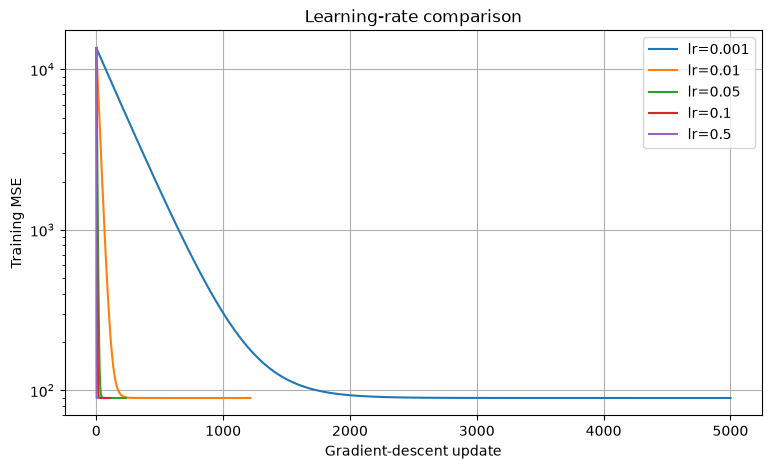

In [10]:
plt.figure(figsize=(9, 5))

for learning_rate, model in learning_rate_results.items():
    plt.plot(
        model.loss_history_,
        label=f"lr={learning_rate}",
    )

plt.xlabel("Gradient-descent update")
plt.ylabel("Training MSE")
plt.title("Learning-rate comparison")
plt.yscale("log")
plt.legend()
plt.grid()

plt.show()

In [11]:
X, y = load_diabetes(
    return_X_y=True,
    scaled=False,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [12]:
gd_diabetes = LinearRegressionGD(
    learning_rate=0.1,
    max_iterations=20_000,
    gradient_tolerance=1e-6,
)

gd_diabetes.fit(
    X_train_scaled,
    y_train,
)

sklearn_diabetes = LinearRegression()

sklearn_diabetes.fit(
    X_train_scaled,
    y_train,
)


gd_test_predictions = gd_diabetes.predict(
    X_test_scaled
)

sklearn_test_predictions = (
    sklearn_diabetes.predict(
        X_test_scaled
    )
)


print("CUSTOM GRADIENT DESCENT")
print(
    "Test MSE:",
    mean_squared_error(
        y_test,
        gd_test_predictions,
    ),
)
print(
    "Test R²:",
    r2_score(
        y_test,
        gd_test_predictions,
    ),
)


print("\nSCIKIT-LEARN")
print(
    "Test MSE:",
    mean_squared_error(
        y_test,
        sklearn_test_predictions,
    ),
)
print(
    "Test R²:",
    r2_score(
        y_test,
        sklearn_test_predictions,
    ),
)


print(
    "\nMean prediction difference:",
    np.mean(
        np.abs(
            gd_test_predictions
            - sklearn_test_predictions
        )
    ),
)

CUSTOM GRADIENT DESCENT
Test MSE: 2900.193596548925
Test R²: 0.4526027690012968

SCIKIT-LEARN
Test MSE: 2900.193628493482
Test R²: 0.45260276297191937

Mean prediction difference: 3.484153544192257e-06


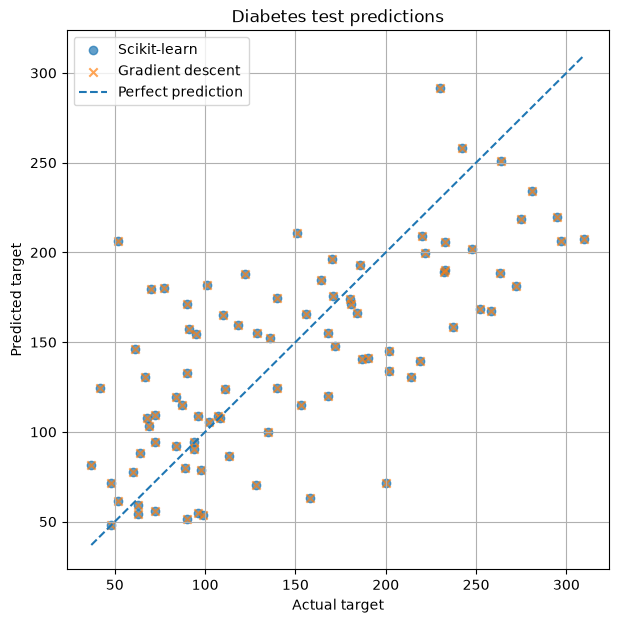

In [13]:
minimum = min(
    y_test.min(),
    gd_test_predictions.min(),
    sklearn_test_predictions.min(),
)

maximum = max(
    y_test.max(),
    gd_test_predictions.max(),
    sklearn_test_predictions.max(),
)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    sklearn_test_predictions,
    alpha=0.7,
    label="Scikit-learn",
)

plt.scatter(
    y_test,
    gd_test_predictions,
    alpha=0.7,
    marker="x",
    label="Gradient descent",
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect prediction",
)

plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Diabetes test predictions")
plt.legend()
plt.grid()

plt.show()